In [1]:
# !pip install jax jaxlib matplotlib

import jax
import jax.numpy as jnp
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f'JAX version: {jax.__version__}')
print(f'Device: {jax.devices()}')

JAX version: 0.7.2
Device: [CudaDevice(id=0)]


In [2]:
# Define two versions of the same function
# one has @jax.jit and one does not

def compute_eager(x):
    x = jnp.sin(x)
    x = x * 2.0 + 1.0
    c = x / 2
    x = jnp.cos(x)
    d = x + c
    e = jnp.exp(d)
    f = jnp.log(jnp.abs(e))
    x = f ** 4
    x = jnp.tanh(x)
    x = jnp.sqrt(jnp.abs(x))
    return x

@jax.jit
def compute_jit(x):
    x = jnp.sin(x)
    x = x * 2.0 + 1.0
    c = x / 2
    x = jnp.cos(x)
    d = x + c
    e = jnp.exp(d)
    f = jnp.log(jnp.abs(e))
    x = f ** 4
    x = jnp.tanh(x)
    x = jnp.sqrt(jnp.abs(x))
    return x

In [13]:
sizes       = [100, 500, 1000, 5000]
eager_times = []
jit_first   = []
jit_cached  = []

for size in sizes:
    x = jax.random.normal(jax.random.PRNGKey(0), (size, size), dtype=jnp.float32)

    # Time eager mode
    t0 = time.perf_counter()
    jax.block_until_ready(compute_eager(x))
    eager_times.append((time.perf_counter() - t0) * 1000)

    # Time JIT first call — clear cache to force recompilation
    compute_jit.clear_cache()
    t0 = time.perf_counter()
    jax.block_until_ready(compute_jit(x))
    jit_first.append((time.perf_counter() - t0) * 1000)

    # Time JIT cached — kernel already compiled, runs directly
    t0 = time.perf_counter()
    jax.block_until_ready(compute_jit(x))
    jit_cached.append((time.perf_counter() - t0) * 1000)

    print(f'{size}x{size} | Eager: {eager_times[-1]:.1f}ms | JIT first: {jit_first[-1]:.1f}ms | JIT cached: {jit_cached[-1]:.1f}ms')

100x100 | Eager: 3.0ms | JIT first: 91.3ms | JIT cached: 0.2ms
500x500 | Eager: 1.9ms | JIT first: 137.5ms | JIT cached: 0.2ms
1000x1000 | Eager: 1.8ms | JIT first: 146.8ms | JIT cached: 0.2ms
5000x5000 | Eager: 12.5ms | JIT first: 141.5ms | JIT cached: 1.2ms


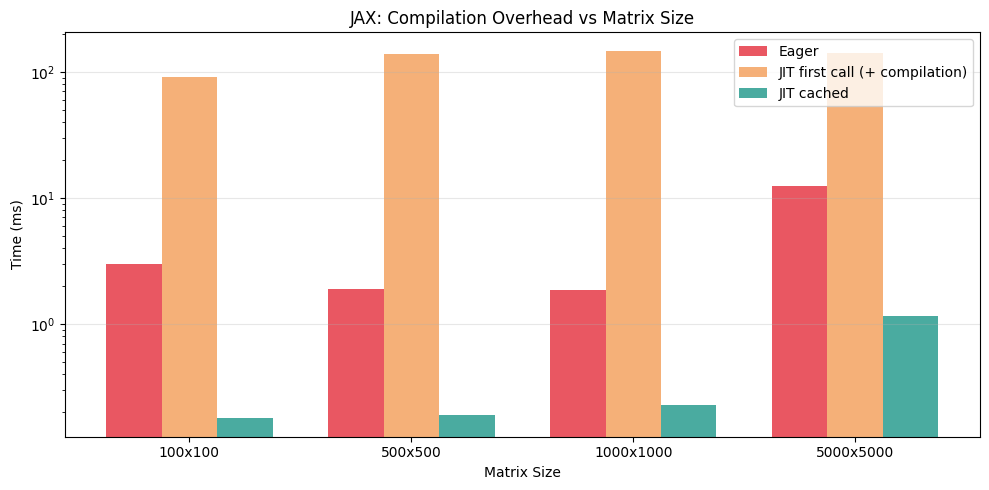

In [14]:
# Plot: execution time vs matrix size

x_pos  = np.arange(len(sizes))
width  = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width, eager_times, width, label='Eager',                            color='#e63946', alpha=0.85)
ax.bar(x_pos,         jit_first,   width, label='JIT first call (+ compilation)',   color='#f4a261', alpha=0.85)
ax.bar(x_pos + width, jit_cached,  width, label='JIT cached',                       color='#2a9d8f', alpha=0.85)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{s}x{s}' for s in sizes])
ax.set_xlabel('Matrix Size')
ax.set_ylabel('Time (ms)')
ax.set_title('JAX: Compilation Overhead vs Matrix Size')
ax.set_yscale('log')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('part1_compilation_overhead.png', bbox_inches='tight')
plt.show()

#Why does the overhead vary with matrix size?

As the matrix size increases the eager mode becomes slower because it launches 10 kernels that read and write from global global memory. As the matrix becomes larger, the overhead for the repetitive memory trips becomes time consuming. The JIT first call spikes with the largest matrix because execution time becomes large enough to add on top of the fixed compilation cost. The JIT cached section does not include the tracing or compiliation overhead but slowly increases due to the amount of calculations.

---
## Part 2: Shape Specialization

In [5]:
#JIT compiled row mean function

@jax.jit
def row_mean(x):
    jax.debug.print('TRACING for shape: {}', x.shape)
    return jnp.mean(x, axis=1)

In [6]:
# Call with 4 different shapes and observe retracing

test_shapes = [
    ((100, 100), 'first call — compiles'),
    ((100, 200), 'new shape — recompiles'),
    ((100, 100), 'same as call 1 — cache hit'),
    ((200, 100), 'new shape — recompiles'),
]

times  = []
labels = []
colors = []

print('Calling row_mean with different shapes:')
print('(TRACING message only prints when JAX retraces)')
print('=' * 55)

for i, (shape, desc) in enumerate(test_shapes):
    x = jax.random.normal(jax.random.PRNGKey(i), shape, dtype=jnp.float32)

    t0 = time.perf_counter()
    jax.block_until_ready(row_mean(x))
    elapsed = (time.perf_counter() - t0) * 1000

    times.append(elapsed)
    labels.append(f'Call {i+1}\n{shape}')
    colors.append('#2a9d8f' if shape == (100, 100) and i == 2 else '#f4a261')

    print(f'Call {i+1}: shape={shape} | {desc} | {elapsed:.2f} ms')

Calling row_mean with different shapes:
(TRACING message only prints when JAX retraces)
TRACING for shape: (Array(100, dtype=int32), Array(100, dtype=int32))
Call 1: shape=(100, 100) | first call — compiles | 88.50 ms
TRACING for shape: (Array(100, dtype=int32), Array(200, dtype=int32))
Call 2: shape=(100, 200) | new shape — recompiles | 69.55 ms
TRACING for shape: (Array(100, dtype=int32), Array(100, dtype=int32))
Call 3: shape=(100, 100) | same as call 1 — cache hit | 1.17 ms
TRACING for shape: (Array(200, dtype=int32), Array(100, dtype=int32))
Call 4: shape=(200, 100) | new shape — recompiles | 65.74 ms


In [7]:
for shape in [(100,100), (200,100)]:
    print(f'\nJAXPR for {shape}:')
    print(jax.make_jaxpr(row_mean)(jnp.ones(shape)))


JAXPR for (100, 100):
{ lambda ; a:f32[100,100]. let
    b:f32[100] = jit[
      name=row_mean
      jaxpr={ lambda ; a:f32[100,100]. let
          debug_print[
            fmt=TRACING for shape: {}
            has_placeholders=True
            in_tree=PyTreeDef((((*, *),), {}))
            np_printoptions=(('edgeitems', 3), ('threshold', 1000), ('floatmode', 'maxprec'), ('precision', 8), ('suppress', False), ('linewidth', 75), ('nanstr', 'nan'), ('infstr', 'inf'), ('sign', '-'), ('formatter', None), ('legacy', False))
            ordered=False
            partitioned=False
            static_args=()
          ] 100:i32[] 100:i32[]
          c:f32[100] = reduce_sum[axes=(1,)] a
          b:f32[100] = div c 100.0:f32[]
        in (b,) }
    ] a
  in (b,) }

JAXPR for (200, 100):
{ lambda ; a:f32[200,100]. let
    b:f32[200] = jit[
      name=row_mean
      jaxpr={ lambda ; a:f32[200,100]. let
          debug_print[
            fmt=TRACING for shape: {}
            has_placeholders=True

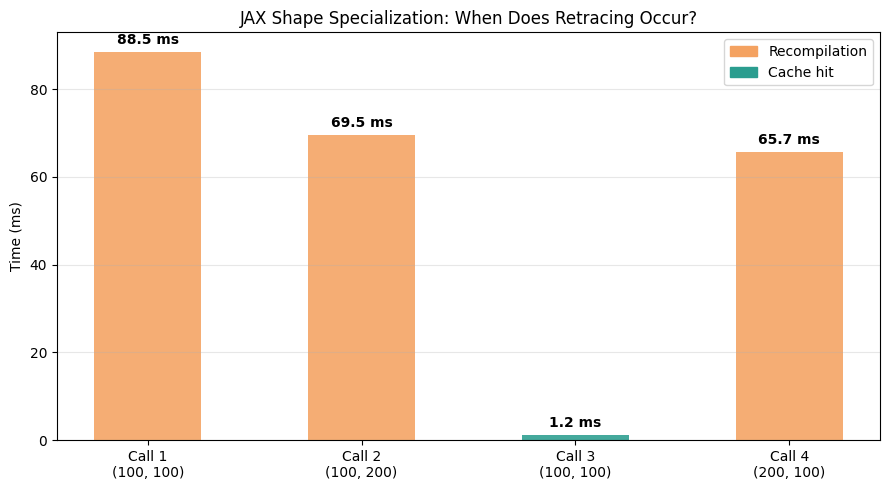

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, times, color=colors, width=0.5, alpha=0.88)

for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(times) * 0.02,
            f'{t:.1f} ms', ha='center', fontsize=10, fontweight='bold')

ax.legend(handles=[
    mpatches.Patch(color='#f4a261', label='Recompilation'),
    mpatches.Patch(color='#2a9d8f', label='Cache hit')
])
ax.set(ylabel='Time (ms)', title='JAX Shape Specialization: When Does Retracing Occur?')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### When does JAX retrace? What is the performance impact?

JAX retraces whenever the input shape or dtype changes. It stores a compiled version per (shape, dtype) combination. (100,100) is a cold start that traces, compiles, and caches. (100,200) is a new input shape and recompiles. (100,100) is a cache hit and runs fast. The performance impact for recompilation costs 70-90ms, while the cache hit is 4.4ms. Training loops with changing batch sizes or sequence length will increase the overhead quickly.


# Part 3: Operator Fusion Analysis

In [9]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = torch.randn(5000, 5000, device=device)

# Version A: Eager
def f_eager(x):
    total = torch.zeros_like(x)
    sin_x = x
    cos_x = x
    for _ in range(100):
        sin_x = torch.sin(sin_x)
        cos_x = torch.cos(cos_x)
        total = total + sin_x + cos_x
    return total

# Version B: JIT compiled
@torch.compile
def f_jit(x):
    total = torch.zeros_like(x)
    sin_x = x
    cos_x = x
    for _ in range(100):
        sin_x = torch.sin(sin_x)
        cos_x = torch.cos(cos_x)
        total = total + sin_x + cos_x
    return total

In [10]:
from torch.profiler import profile, ProfilerActivity

# Warmup
f_eager(x)
f_jit(x)
torch.cuda.synchronize()

# Profile eager
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as p:
    f_eager(x)
print('=== EAGER ===')
print(p.key_averages().table(sort_by='cuda_time_total', row_limit=5))

# Profile JIT
with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA]) as p:
    f_jit(x)
print('=== JIT ===')
print(p.key_averages().table(sort_by='cpu_time_total', row_limit=5))

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


=== EAGER ===
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::add         0.32%       1.361ms         0.57%       2.386ms      11.929us     247.663ms        59.17%     247.663ms       1.238ms           200  
void at::native::vectorized_elementwise_kernel<4, at...         0.00%       0.000us         0.00%       0.000us       0.000us     247.663ms        59.17%     247.663ms       1.238ms           2

#Part 3 Analysis

**Why does the JIT version achieve better performance?**

torch.compile traces through the loop and compile the operations into one kernel. It uses registers to hold intermediate results while eager version will launch 400 kernels for each operation and the kernels will write results to global memory.

**How many operations were fused?**

The sin, cos, and add operations in eager version is a total of 400 operations.
triton_poi_fused_add_cos_sin_0 will fuse the 400 operations into 1 kernel.

**Theoretical vs actual speedup:**

The theoretical memory traffic speedup is 1000/2 for a reduction of 500x. The actual speedup from is calculated from Eager versions recording of 418ms compared to 302ms from the triton fusion kernel. About an actual speedup of 1.4x for my runtime recordings. This is not close to theoretical speedup because of syncronization.